# Self-Refine on the small tier

A Self-Refine move costs five model calls instead of one: an initial draft plus
two critique-and-rewrite iterations. This notebook asks whether that fivefold
inference cost buys a measurable improvement in negotiation outcomes, and, if it
does not, what the refinement loop actually does to a move.

The analysis is restricted to the **small tier** (12–14B: Gemma 3 12B,
Ministral 3 14B, Qwen3 14B). The experiment is self-play: in every game both
seats are the same model, and each of the four strategy assignments is run
30 times per model. The assignments are coded by two letters, the first for
Player 1 and the second for Player 2, with `D` = default and `R` = self-refine:

| code | Player 1 | Player 2 |
|------|----------|----------|
| `DD` | default  | default  |
| `RD` | refine   | default  |
| `DR` | default  | refine   |
| `RR` | refine   | refine   |

The `RD` and `DR` cells are the workhorses: each isolates the effect of adding
refinement to a single seat while the opponent stays on default, which lets us
estimate the refine effect without confounding it with the large first/second
mover asymmetries documented in the benchmark chapter.

In [1]:
import sys, os, json, warnings
from pathlib import Path


def find_repo_root():
    starts = []
    seen = set()

    def add_start(path_like):
        if not path_like:
            return
        try:
            path = Path(path_like).resolve()
        except (FileNotFoundError, OSError, RuntimeError):
            return
        key = str(path)
        if key not in seen:
            seen.add(key)
            starts.append(path)

    if "__file__" in globals():
        add_start(Path(__file__).resolve().parent)
    try:
        add_start(Path.cwd())
    except (FileNotFoundError, OSError, RuntimeError):
        pass
    add_start(os.environ.get("PWD"))
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))
sys.path.insert(0, str(ROOT_DIR / "explorer"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

import style
from style import wilson_ci, bootstrap_ci, errbars_from_ci, win_rate, family_of
# Publication design system (_notebooks/oss/style): sans-serif report skin,
# colorblind palette, value-axis gridlines, and constrained layout.
style.apply_thesis_style()
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

NOTEBOOK_NAME = "3_self_refine"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    """Save without the descriptive whole-figure title (the LaTeX caption supplies
    it); keep panel titles and keep the title for the inline display. Writes a PNG
    and a vector PDF beside it."""
    hidden = []
    sup = getattr(fig, "_suptitle", None)
    if sup is not None and sup.get_text():
        sup.set_visible(False); hidden.append(sup)
    real_axes = [a for a in fig.axes if a.get_label() != "<colorbar>"]
    if len(real_axes) == 1 and real_axes[0].get_title():
        t = real_axes[0].title
        t.set_visible(False); hidden.append(t)
    for ext in ("png", "pdf"):
        fig.savefig(FIG_DIR / f"{slug}.{ext}", dpi=300, bbox_inches="tight")
    for artist in hidden:
        artist.set_visible(True)
    return FIG_DIR / f"{slug}.png"


SIZE = "small"
GAME_ORDER = ["Trading", "Ultimatum", "BuySell"]
COND_ORDER = ["DD", "RD", "DR", "RR"]
COND_LABEL = {"DD": "default", "RD": "refine P1", "DR": "refine P2", "RR": "both refine"}
# Strategy-condition palette (grey baseline, blue single-seat refine, green both).
COND_COLORS = {"DD": "#8C8C8C", "RD": "#0173b2", "DR": "#56b4e9", "RR": "#029e73"}
# Focal-party setting palette for the seat-controlled comparison.
SETTING_ORDER = ["default", "refine", "both"]
SETTING_LABEL = {"default": "default", "refine": "refine (one seat)", "both": "both refine"}
SETTING_COLORS = {"default": "#8C8C8C", "refine": "#0173b2", "both": "#029e73"}
# Process direction palette (matches the Streamlit page).
DIRECTION_ORDER = ["more_selfish", "unchanged", "more_generous", "no_proposal"]
DIRECTION_LABEL = {"more_selfish": "more selfish", "unchanged": "unchanged",
                   "more_generous": "more generous", "no_proposal": "no proposal"}
DIRECTION_COLORS = {"more_selfish": "#d55e00", "unchanged": "#8C8C8C",
                    "more_generous": "#0173b2", "no_proposal": "#ece133"}
GAME_NATIVE_UNIT = {"Trading": "resource delta", "Ultimatum": "dollars kept",
                    "BuySell": "surplus (ZUP)"}

## Data

Outcomes come from the per-run `game_state.json` files via the project's
outcome loaders; the refinement process comes from the per-turn
`refine_trace_*.json` files via the trace loaders. Both are filtered to the
small tier. Payoff is reported in each game's native unit: net resource change
in Trading, dollars kept in Ultimatum, and surplus over the reservation value in
BuySell.

In [2]:
from analysis.self_refine import (
    load_trading_sr, load_ultimatum_sr, load_buysell_sr, completion_rows,
)
from analysis.self_refine_process import load_trace_rows, load_trace_summary

OUT = {
    "Trading": load_trading_sr(SIZE),
    "Ultimatum": load_ultimatum_sr(SIZE),
    "BuySell": load_buysell_sr(SIZE),
}
for g, df in OUT.items():
    df["game"] = g
    df["family"] = df["model"].map(family_of)

COMP = completion_rows(SIZE)
TRACE = load_trace_rows()
TRACE = TRACE[TRACE["size"] == SIZE].copy()
TSUM = load_trace_summary()
TSUM = TSUM[TSUM["size"] == SIZE].copy()

# Sample sizes: completed decisive games underpin every win rate, so show them.
size_tbl = []
for g, df in OUT.items():
    for c in COND_ORDER:
        sub = df[df["cond"] == c]
        decisive = int((sub["win_1"] | sub["win_2"]).sum())
        size_tbl.append({"game": g, "cond": c, "completed": len(sub),
                         "decisive": decisive})
size_tbl = pd.DataFrame(size_tbl).pivot_table(
    index="game", columns="cond", values=["completed", "decisive"]).reindex(GAME_ORDER)
print("Completed runs / decisive (non-tied) games per game x condition:\n")
print(size_tbl.to_string())

2026-06-16 02:03:12.934 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-06-16 02:03:12.940 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-06-16 02:03:14.339 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-06-16 02:03:14.339 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


2026-06-16 02:03:22.154 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


2026-06-16 02:03:22.156 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


Completed runs / decisive (non-tied) games per game x condition:

          completed                   decisive                  
cond             DD    DR    RD    RR       DD    DR    RD    RR
game                                                            
Trading        73.0  88.0  86.0  84.0     57.0  73.0  78.0  76.0
Ultimatum      80.0  89.0  83.0  78.0     59.0  67.0  59.0  62.0
BuySell        84.0  88.0  87.0  87.0     70.0  82.0  78.0  85.0


## 1. Completion

One of the five critique axes is *format*: whether every required tag is present
and parseable. If refinement helps anywhere mechanically rather than
strategically, it is here, by catching a malformed move before it is committed.
Completion on the small tier is already high, so the question is whether
refinement closes the remaining gap.

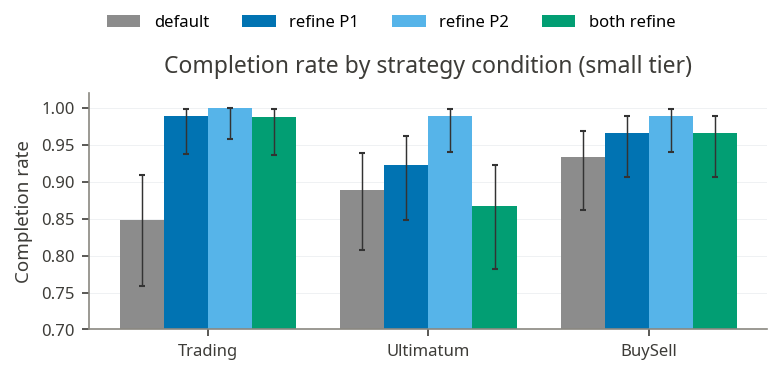

cond          DD     RD     DR     RR
game                                 
Trading    0.849  0.989  1.000  0.988
Ultimatum  0.889  0.922  0.989  0.867
BuySell    0.933  0.967  0.989  0.967


In [3]:
cc = (COMP.groupby(["game", "cond"])
      .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
cc["rate"] = cc["k"] / cc["n"]
cc[["lo", "hi"]] = cc.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)

x = np.arange(len(GAME_ORDER)); width = 0.2
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.85, 2.4))
for i, c in enumerate(COND_ORDER):
    sub = cc[cc["cond"] == c].set_index("game").reindex(GAME_ORDER)
    pos = x + (i - 1.5) * width
    ax.bar(pos, sub["rate"], width, label=COND_LABEL[c], color=COND_COLORS[c])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.set_xticks(x, GAME_ORDER); ax.set_ylabel("Completion rate"); ax.set_ylim(0.7, 1.02)
ax.set_title("Completion rate by strategy condition (small tier)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=4, frameon=False)
save_plot(fig, "completion_by_condition"); plt.show()

print(cc.pivot_table(index="game", columns="cond", values="rate")
      .reindex(index=GAME_ORDER, columns=COND_ORDER).round(3).to_string())

Completion ranges from 0.85 to 1.00. It is flat across conditions in
Ultimatum and BuySell, where the four intervals overlap. Trading is the
exception: the both-default cell completes 0.849 [0.758, 0.909], while every
condition containing a refiner completes at least 0.988, intervals that do not
overlap. In the one game where the small tier still drops moves on default, a
refiner in the loop recovers them — the format critique catching malformed trades
before they end the game. This is the clearest mechanical benefit refinement
provides; whether it also improves the negotiated outcome is the next
question.

## 2. Does refinement change the outcome?

To estimate the effect of refinement cleanly we hold the seat fixed and compare
the focal party with and without the loop, keeping its opponent on default:

- **refine (one seat)** pools Player 1 in `RD` with Player 2 in `DR`,
- against the matched **default** baseline of Player 1 and Player 2 in `DD`,
- and **both refine** pools both seats of `RR`.

Pooling one P1-seat group with one P2-seat group keeps the comparison balanced
across the strong first/second-mover asymmetry, so any gap between the bars is
attributable to refinement rather than to seating.

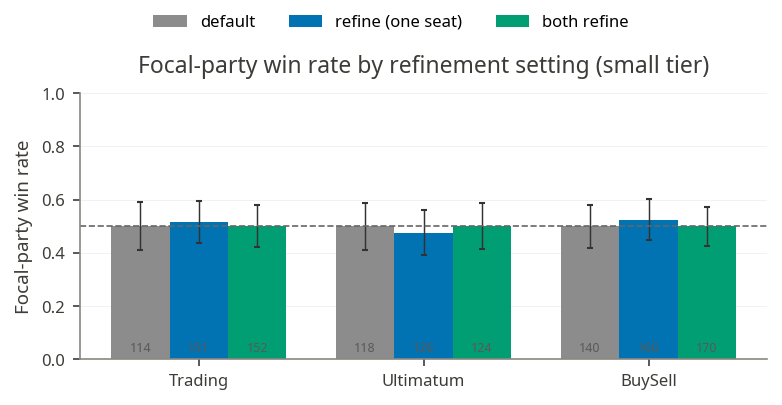

setting    default  refine  both
game                            
Trading        0.5   0.517   0.5
Ultimatum      0.5   0.476   0.5
BuySell        0.5   0.525   0.5


In [4]:
def focal_frame(df):
    """Long frame of the focal party's outcome, seat-balanced, by setting."""
    recs = []

    def add(sub, seat, setting):
        if seat == 1:
            pay, w, l = sub["payoff_1"], sub["win_1"], sub["win_2"]
        else:
            pay, w, l = sub["payoff_2"], sub["win_2"], sub["win_1"]
        for p, win, loss in zip(pay, w, l):
            recs.append(dict(setting=setting, seat=seat, payoff=float(p),
                             win=bool(win), loss=bool(loss)))

    add(df[df["cond"] == "DD"], 1, "default"); add(df[df["cond"] == "DD"], 2, "default")
    add(df[df["cond"] == "RD"], 1, "refine");  add(df[df["cond"] == "DR"], 2, "refine")
    add(df[df["cond"] == "RR"], 1, "both");    add(df[df["cond"] == "RR"], 2, "both")
    return pd.DataFrame(recs)


FOCAL = {g: focal_frame(df) for g, df in OUT.items()}

# Win rate (ties excluded) of the focal party, with Wilson CIs.
rows = []
for g, ff in FOCAL.items():
    for s in SETTING_ORDER:
        sub = ff[ff["setting"] == s]
        wins, losses = int(sub["win"].sum()), int(sub["loss"].sum())
        rate, k, n = win_rate(wins, losses)
        lo, hi = wilson_ci(k, n)
        rows.append(dict(game=g, setting=s, rate=rate, k=k, n=n, lo=lo, hi=hi))
wr = pd.DataFrame(rows)

x = np.arange(len(GAME_ORDER)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.85, 2.6))
for i, s in enumerate(SETTING_ORDER):
    sub = wr[wr["setting"] == s].set_index("game").reindex(GAME_ORDER)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=SETTING_LABEL[s], color=SETTING_COLORS[s])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    for xp, r, n in zip(pos, sub["rate"], sub["n"]):
        if np.isfinite(r):
            ax.annotate(f"{int(n)}", (xp, 0.02), ha="center", va="bottom",
                        fontsize=6, color="0.35")
ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
ax.set_xticks(x, GAME_ORDER); ax.set_ylabel("Focal-party win rate"); ax.set_ylim(0, 1.0)
ax.set_title("Focal-party win rate by refinement setting (small tier)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=3, frameon=False)
save_plot(fig, "winrate_refine_effect"); plt.show()

print(wr.assign(rate=wr["rate"].round(3))
        .pivot_table(index="game", columns="setting", values="rate")
        .reindex(index=GAME_ORDER, columns=SETTING_ORDER).to_string())

Win rate is a within-pair quantity: in self-play one seat's win is the
other's loss, so a value near 0.5 means the seat the refiner happens to occupy is
neither helped nor hurt relative to a default opponent. The dashed line marks
that parity; the *default* baseline sits exactly on it by construction, since
pooling both seats of a self-play game forces wins to equal losses. Read against
that line, the focal-party win rate moves little when one seat adds refinement —
0.52 in Trading, 0.48 in Ultimatum, 0.53 in BuySell — and every *refine* Wilson
interval contains 0.5. The payoff view below carries the units the win rate
discards.

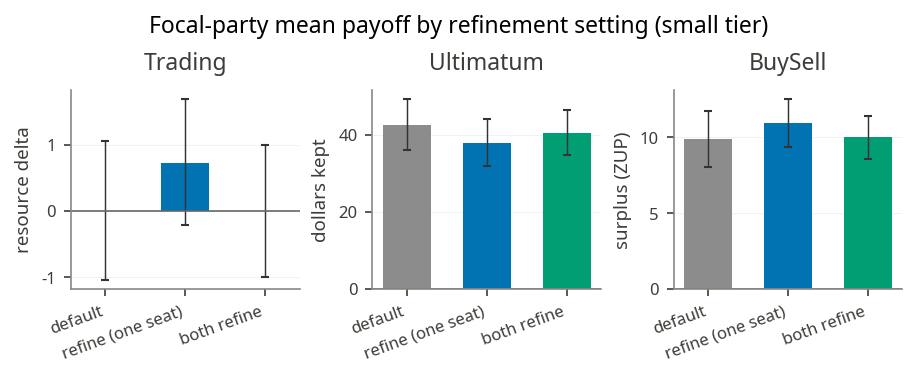

Trading    default=  0.00  refine=  0.73  delta=+0.73 (resource delta)
Ultimatum  default= 42.50  refine= 37.87  delta=-4.63 (dollars kept)
BuySell    default=  9.88  refine= 10.94  delta=+1.06 (surplus (ZUP))


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.4))
for ax, g in zip(axes, GAME_ORDER):
    ff = FOCAL[g]
    centers, los, his = [], [], []
    for s in SETTING_ORDER:
        vals = ff[ff["setting"] == s]["payoff"].values
        centers.append(np.mean(vals))
        lo, hi = bootstrap_ci(vals)
        los.append(lo); his.append(hi)
    pos = np.arange(len(SETTING_ORDER))
    ax.bar(pos, centers, 0.6, color=[SETTING_COLORS[s] for s in SETTING_ORDER])
    ax.errorbar(pos, centers,
                yerr=errbars_from_ci(centers, list(zip(los, his))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=2)
    ax.axhline(0, lw=0.8, color="0.4")
    ax.set_xticks(pos, [SETTING_LABEL[s] for s in SETTING_ORDER], rotation=20, ha="right")
    ax.set_title(g); ax.set_ylabel(GAME_NATIVE_UNIT[g])
fig.suptitle("Focal-party mean payoff by refinement setting (small tier)")
save_plot(fig, "payoff_refine_effect"); plt.show()

for g in GAME_ORDER:
    ff = FOCAL[g]
    base = ff[ff["setting"] == "default"]["payoff"].values
    ref = ff[ff["setting"] == "refine"]["payoff"].values
    delta = np.mean(ref) - np.mean(base)
    print(f"{g:10s} default={np.mean(base):6.2f}  refine={np.mean(ref):6.2f}  "
          f"delta={delta:+5.2f} ({GAME_NATIVE_UNIT[g]})")

<!-- INSIGHTS_OUTCOME -->
Across all three games the *refine* bar lands within the bootstrap interval of
the *default* bar, and *both refine* does not separate either. Spending five
calls per move in place of one does not move the focal party's payoff at the
small tier. The outcome is flat; the next section asks whether the moves
themselves are flat, or whether refinement is changing the move in a way that
the opponent simply absorbs.

## 3. What refinement does to a move

Outcomes being flat does not mean the loop is inert. Each refining turn leaves a
trace of the draft and its two rewrites, from which we recover the proposed
offer at each version. `ambition_delta` is defined so that a positive value means
the proposer became **more selfish** between its initial draft and its committed
move (the sign is flipped for the BuySell buyer, whose self-interest runs in the
opposite price direction). `direction` buckets each refined move accordingly.

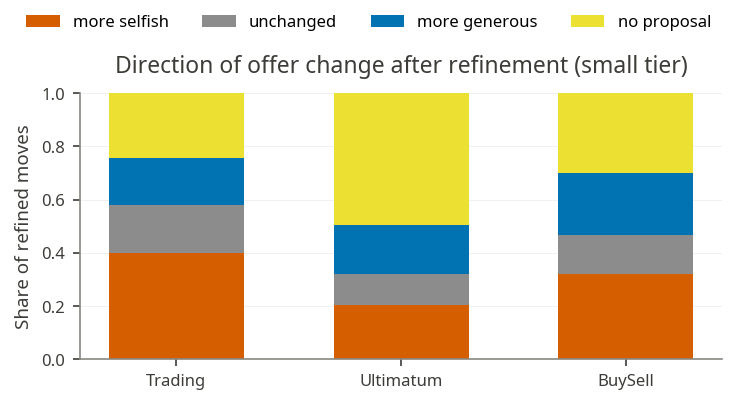

Trading    more-selfish share among changed = 0.69 [0.64, 0.74] (n=366);  mean ambition_delta = +0.96
Ultimatum  more-selfish share among changed = 0.53 [0.44, 0.61] (n=137);  mean ambition_delta = -0.26
BuySell    more-selfish share among changed = 0.58 [0.52, 0.64] (n=256);  mean ambition_delta = +1.58


In [6]:
proc = TSUM.copy()
dd = (proc.groupby(["game", "direction"]).size()
      .rename("n").reset_index())
tot = dd.groupby("game")["n"].transform("sum")
dd["share"] = dd["n"] / tot

games_l = ["trading", "ultimatum", "buysell"]
game_disp = {"trading": "Trading", "ultimatum": "Ultimatum", "buysell": "BuySell"}
x = np.arange(len(games_l))
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.8, 2.6))
bottom = np.zeros(len(games_l))
for d in DIRECTION_ORDER:
    vals = (dd[dd["direction"] == d].set_index("game")
            .reindex(games_l)["share"].fillna(0).values)
    ax.bar(x, vals, 0.6, bottom=bottom, label=DIRECTION_LABEL[d], color=DIRECTION_COLORS[d])
    bottom += vals
ax.set_xticks(x, [game_disp[g] for g in games_l])
ax.set_ylabel("Share of refined moves"); ax.set_ylim(0, 1.0)
ax.set_title("Direction of offer change after refinement (small tier)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center", ncols=4, frameon=False)
save_plot(fig, "refine_direction"); plt.show()

# Among moves that did change the offer, how lopsided is the selfish:generous split?
moved = proc[proc["direction"].isin(["more_selfish", "more_generous"])]
for g in games_l:
    sub = moved[moved["game"] == g]
    s = int((sub["direction"] == "more_selfish").sum())
    gen = int((sub["direction"] == "more_generous").sum())
    n = s + gen
    rate, k, nn = win_rate(s, gen)
    lo, hi = wilson_ci(k, nn)
    md_mean = proc[proc["game"] == g]["ambition_delta"].dropna().mean()
    print(f"{game_disp[g]:10s} more-selfish share among changed = {rate:.2f} "
          f"[{lo:.2f}, {hi:.2f}] (n={n});  mean ambition_delta = {md_mean:+.2f}")

Refinement is not a coin flip. In Trading and BuySell the loop pushes the
offer toward the proposer's own advantage more often than away from it, and the
mean `ambition_delta` is positive in both. The critique axis labelled *payoff
alignment* — "does the proposed trade advance the agent's own goal" — is doing
exactly what its name says: it talks the model into asking for more. Ultimatum is
the exception, where the split is closer to even. Yet none of this surfaced in
Section 2, because in self-play the opponent is refining or responding under the
same incentives and absorbs the more selfish ask.

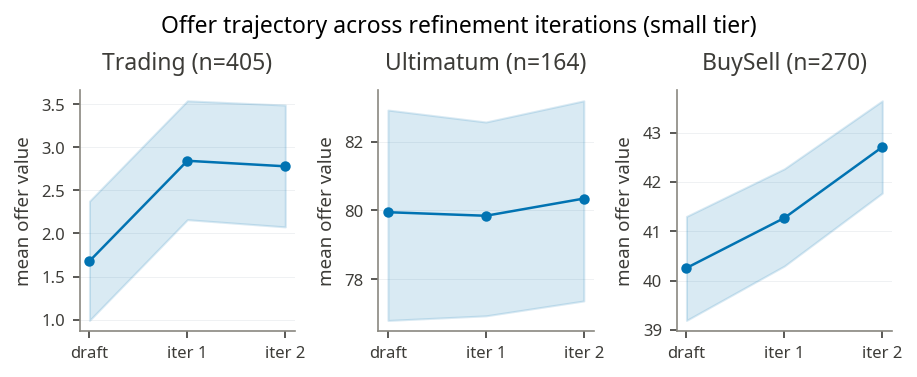

Trading    draft=  1.68 -> iter2=  2.78 (delta +1.10, n=405)
Ultimatum  draft= 79.95 -> iter2= 80.34 (delta +0.40, n=164)
BuySell    draft= 40.26 -> iter2= 42.71 (delta +2.45, n=270)


In [7]:
# Offer trajectory across versions, on matched moves that carry an offer at
# every version (initial -> iter1 -> iter2), so the mean is not biased by
# composition changes between versions.
tr = TRACE.dropna(subset=["offer_value"]).copy()
piv = tr.pivot_table(index=["game", "run_id", "iter_n", "turn_n"],
                     columns="version_idx", values="offer_value")
need = [0, 1, 2]
piv = piv.dropna(subset=[c for c in need if c in piv.columns])
piv = piv.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.4))
for ax, g in zip(axes, games_l):
    sub = piv[piv["game"] == g]
    centers, los, his = [], [], []
    for v in need:
        vals = sub[v].values.astype(float)
        centers.append(np.mean(vals))
        lo, hi = bootstrap_ci(vals)
        los.append(lo); his.append(hi)
    ax.plot(need, centers, "-o", color="#0173b2", lw=1.2, ms=4)
    ax.fill_between(need, los, his, color="#0173b2", alpha=0.15)
    ax.set_xticks(need, ["draft", "iter 1", "iter 2"])
    ax.set_title(f"{game_disp[g]} (n={len(sub)})")
    ax.set_ylabel("mean offer value")
fig.suptitle("Offer trajectory across refinement iterations (small tier)")
save_plot(fig, "offer_trajectory"); plt.show()

for g in games_l:
    sub = piv[piv["game"] == g]
    print(f"{game_disp[g]:10s} draft={sub[0].mean():6.2f} -> iter2={sub[2].mean():6.2f} "
          f"(delta {sub[2].mean() - sub[0].mean():+5.2f}, n={len(sub)})")

The drift is gradual rather than a single jump: where the offer moves, it
moves across both iterations in the same direction, consistent with the
mostly-monotone trajectories quantified below. The loop is not thrashing between
contradictory rewrites; it is steadily nudging the same move.

In [8]:
# Stability: how often refinement flips the action (accept <-> propose) and how
# often the offer path is monotone (no reversal), among traces with >= 3 versions.
rows = []
for g in games_l:
    sub = proc[proc["game"] == g]
    ac = sub["action_changed"].dropna()
    mono = sub["is_monotone"].dropna()
    rows.append({
        "game": game_disp[g],
        "action_flip_rate": round(ac.mean(), 3) if len(ac) else np.nan,
        "n_action": int(len(ac)),
        "monotone_share": round(mono.mean(), 3) if len(mono) else np.nan,
        "n_monotone": int(len(mono)),
    })
stability = pd.DataFrame(rows).set_index("game")
print(stability.to_string())

           action_flip_rate  n_action  monotone_share  n_monotone
game                                                             
Trading               0.103       631           0.583         405
Ultimatum             0.041       319           0.500         164
BuySell               0.078       460           0.500         270


The action rarely flips: refinement keeps the move type it started with —
propose, accept, or reject — in 90 to 96% of turns. The offer path, where it
spans all three versions, is monotone about half the time (0.50–0.58), so the
gradual drift in the previous figure is an average over both steadily-moving and
reversing moves rather than a uniform march. What refinement reliably edits is the
magnitude of an offer, not the decision behind it.

## 4. Summary

On the small tier, Self-Refine changes how a move is written more than how the
game ends. Its one clear mechanical benefit is in Trading, where having a refiner
present lifts completion from 0.85 to near 1.00 by catching malformed trades;
completion is already saturated in the other two games (Section 1). The focal
party's win rate and payoff are otherwise flat, whether it refines one seat, the
other, or both against a default opponent (Section 2). The traces explain the
disconnect: the loop does act, shifting offers toward the proposer's own
advantage in Trading and BuySell and rarely changing the underlying decision
(Section 3), but in self-play the party on the other side operates under the same
incentives and concedes nothing extra to the more selfish ask. Outside of
recovered Trading completions, the five model calls per move are not paid back in
outcome at this tier.